🩺 Breast Cancer Diagnosis Analysis Project

In [1]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats.mstats import winsorize

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib


In [2]:
# SET OPTIONS
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

sns.set_style('darkgrid')

In [3]:
df = pd.read_csv('../Data Set/Breast Cancer.csv')

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.990,10.380,122.800,1001.000,0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,2019.000,0.162,0.666,0.712,0.265,0.460,0.119,NaN
1,842517,M,20.570,17.770,132.900,1326.000,0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,1956.000,0.124,0.187,0.242,0.186,0.275,0.089,NaN
2,84300903,M,19.690,21.250,130.000,1203.000,0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,1709.000,0.144,0.424,0.450,0.243,0.361,0.088,NaN
3,84348301,M,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,0.496,1.156,3.445,27.230,0.009,0.075,0.057,0.019,0.060,0.009,14.910,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173,NaN
4,84358402,M,20.290,14.340,135.100,1297.000,0.100,0.133,0.198,0.104,0.181,0.059,0.757,0.781,5.438,94.440,0.011,0.025,0.057,0.019,0.018,0.005,22.540,16.670,152.200,1575.000,0.137,0.205,0.400,0.163,0.236,0.077,NaN


In [4]:
# Drop unnecessary columns
df.drop(['id','Unnamed: 32'], axis=1, inplace=True)

In [6]:
# Encode target variable
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.990,10.380,122.800,1001.000,0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,2019.000,0.162,0.666,0.712,0.265,0.460,0.119
1,1,20.570,17.770,132.900,1326.000,0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,1956.000,0.124,0.187,0.242,0.186,0.275,0.089
2,1,19.690,21.250,130.000,1203.000,0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,1709.000,0.144,0.424,0.450,0.243,0.361,0.088
3,1,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,0.496,1.156,3.445,27.230,0.009,0.075,0.057,0.019,0.060,0.009,14.910,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173
4,1,20.290,14.340,135.100,1297.000,0.100,0.133,0.198,0.104,0.181,0.059,0.757,0.781,5.438,94.440,0.011,0.025,0.057,0.019,0.018,0.005,22.540,16.670,152.200,1575.000,0.137,0.205,0.400,0.163,0.236,0.077


EDA


In [7]:
print(df['diagnosis'].value_counts())

print(df['diagnosis'].value_counts(normalize=True) * 100)


diagnosis
0    357
1    212
Name: count, dtype: int64
diagnosis
0   62.742
1   37.258
Name: proportion, dtype: float64


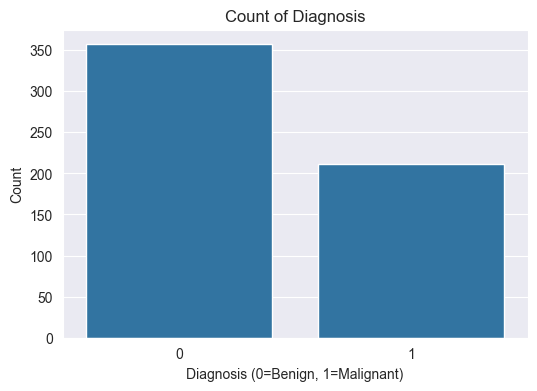

In [ ]:
print(df['diagnosis'].value_counts())

print(df['diagnosis'].value_counts(normalize=True) * 100)


In [ ]:
# Calculate mean values for each feature grouped by diagnosis
mean_df = df.groupby('diagnosis').mean().T

mean_df['diff'] = abs(mean_df[1] - mean_df[0])

print(
    mean_df.sort_values(
        by='diff',
        ascending=False
    ).head(15)
)


diagnosis                  0        1    diff
area_worst           558.899 1422.286 863.387
area_mean            462.790  978.376 515.586
perimeter_worst       87.006  141.370  54.364
area_se               21.135   72.672  51.537
perimeter_mean        78.075  115.365  37.290
radius_worst          13.380   21.135   7.755
texture_worst         23.515   29.318   5.803
radius_mean           12.147   17.463   5.316
texture_mean          17.915   21.605   3.690
perimeter_se           2.000    4.324   2.324
radius_se              0.284    0.609   0.325
concavity_worst        0.166    0.451   0.284
compactness_worst      0.183    0.375   0.192
concavity_mean         0.046    0.161   0.115
concave points_worst   0.074    0.182   0.108


In [11]:
# Top 10 features
top_10_features = mean_df.sort_values(
    'diff',
    ascending=False
).head(10).index
print(top_10_features)


Index(['area_worst', 'area_mean', 'perimeter_worst', 'area_se',
       'perimeter_mean', 'radius_worst', 'texture_worst', 'radius_mean',
       'texture_mean', 'perimeter_se'],
      dtype='str')


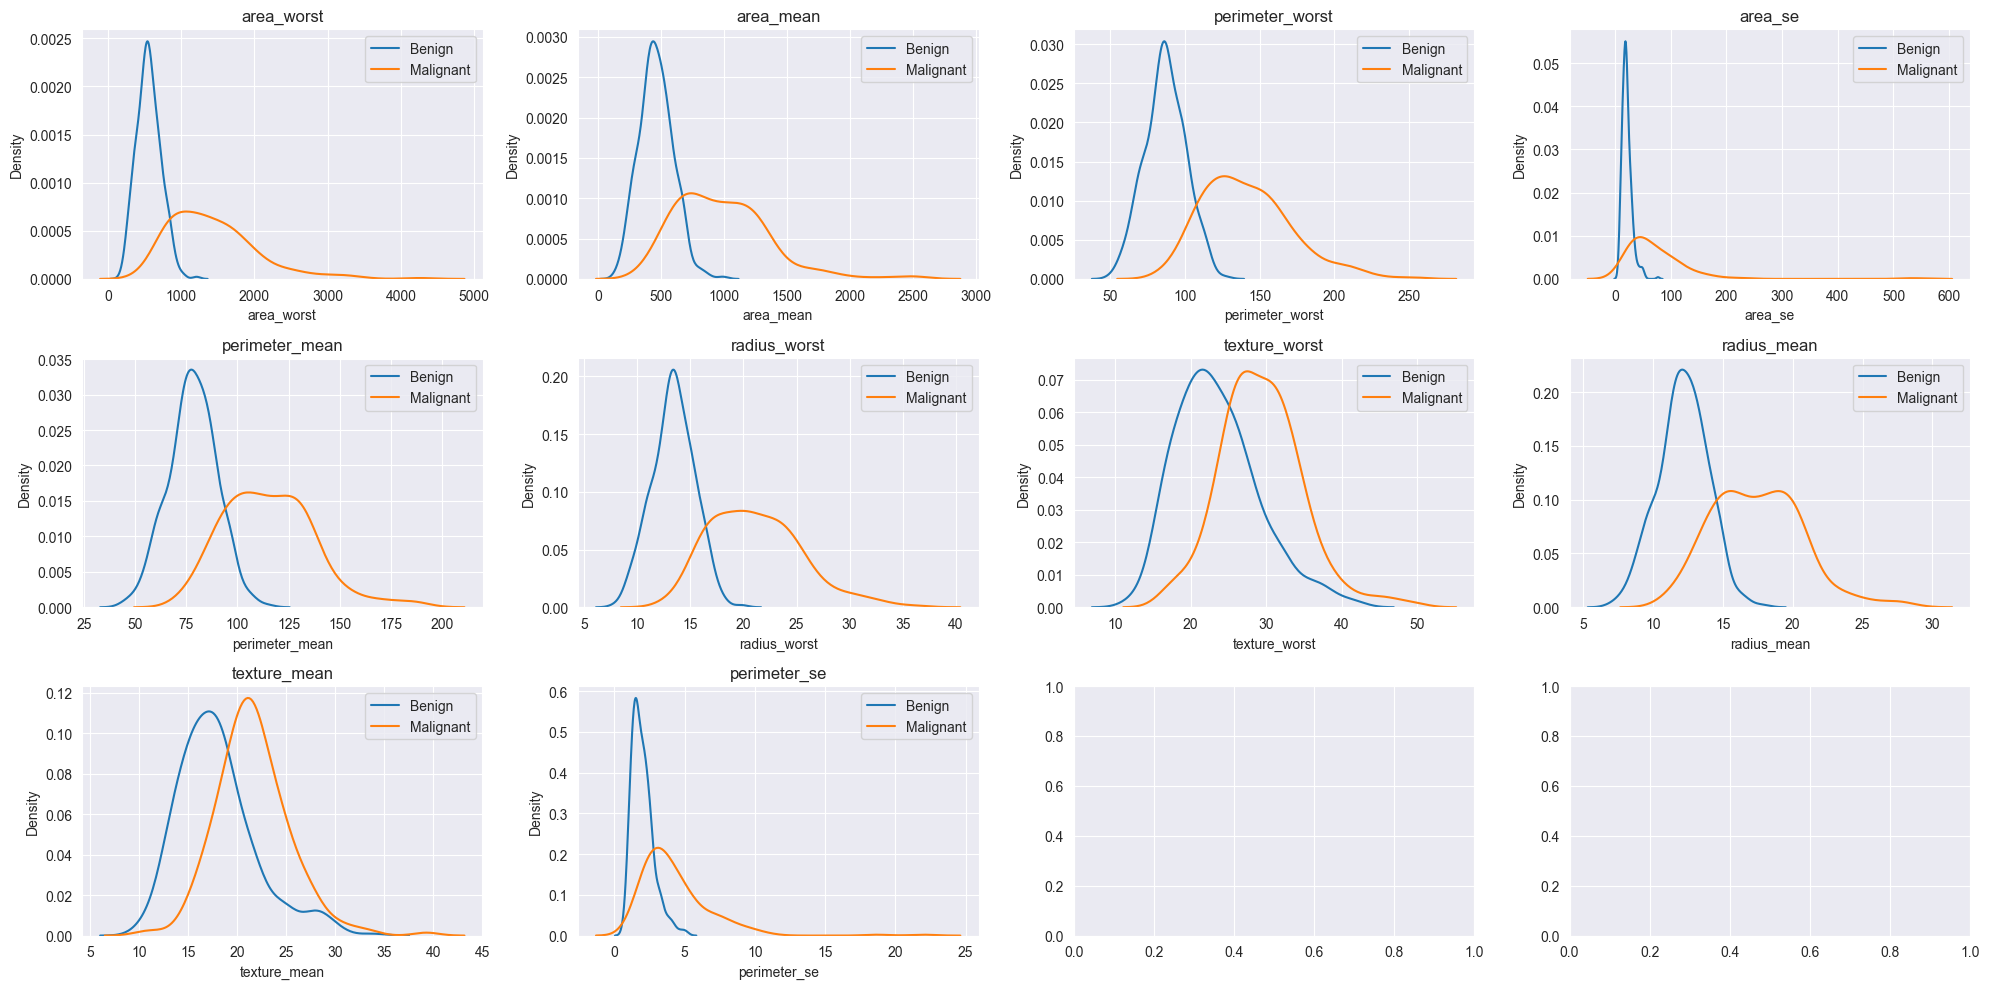

In [12]:
# KDE PLOTS
fig, axes = plt.subplots(3,4, figsize=(20,10))

axes = axes.flatten()

for i, col in enumerate(top_10_features):

    sns.kdeplot(
        df[df['diagnosis']==0][col],
        ax=axes[i],
        label='Benign'
    )

    sns.kdeplot(
        df[df['diagnosis']==1][col],
        ax=axes[i],
        label='Malignant'
    )

    axes[i].set_title(col)

    axes[i].legend()

plt.tight_layout()

plt.show()

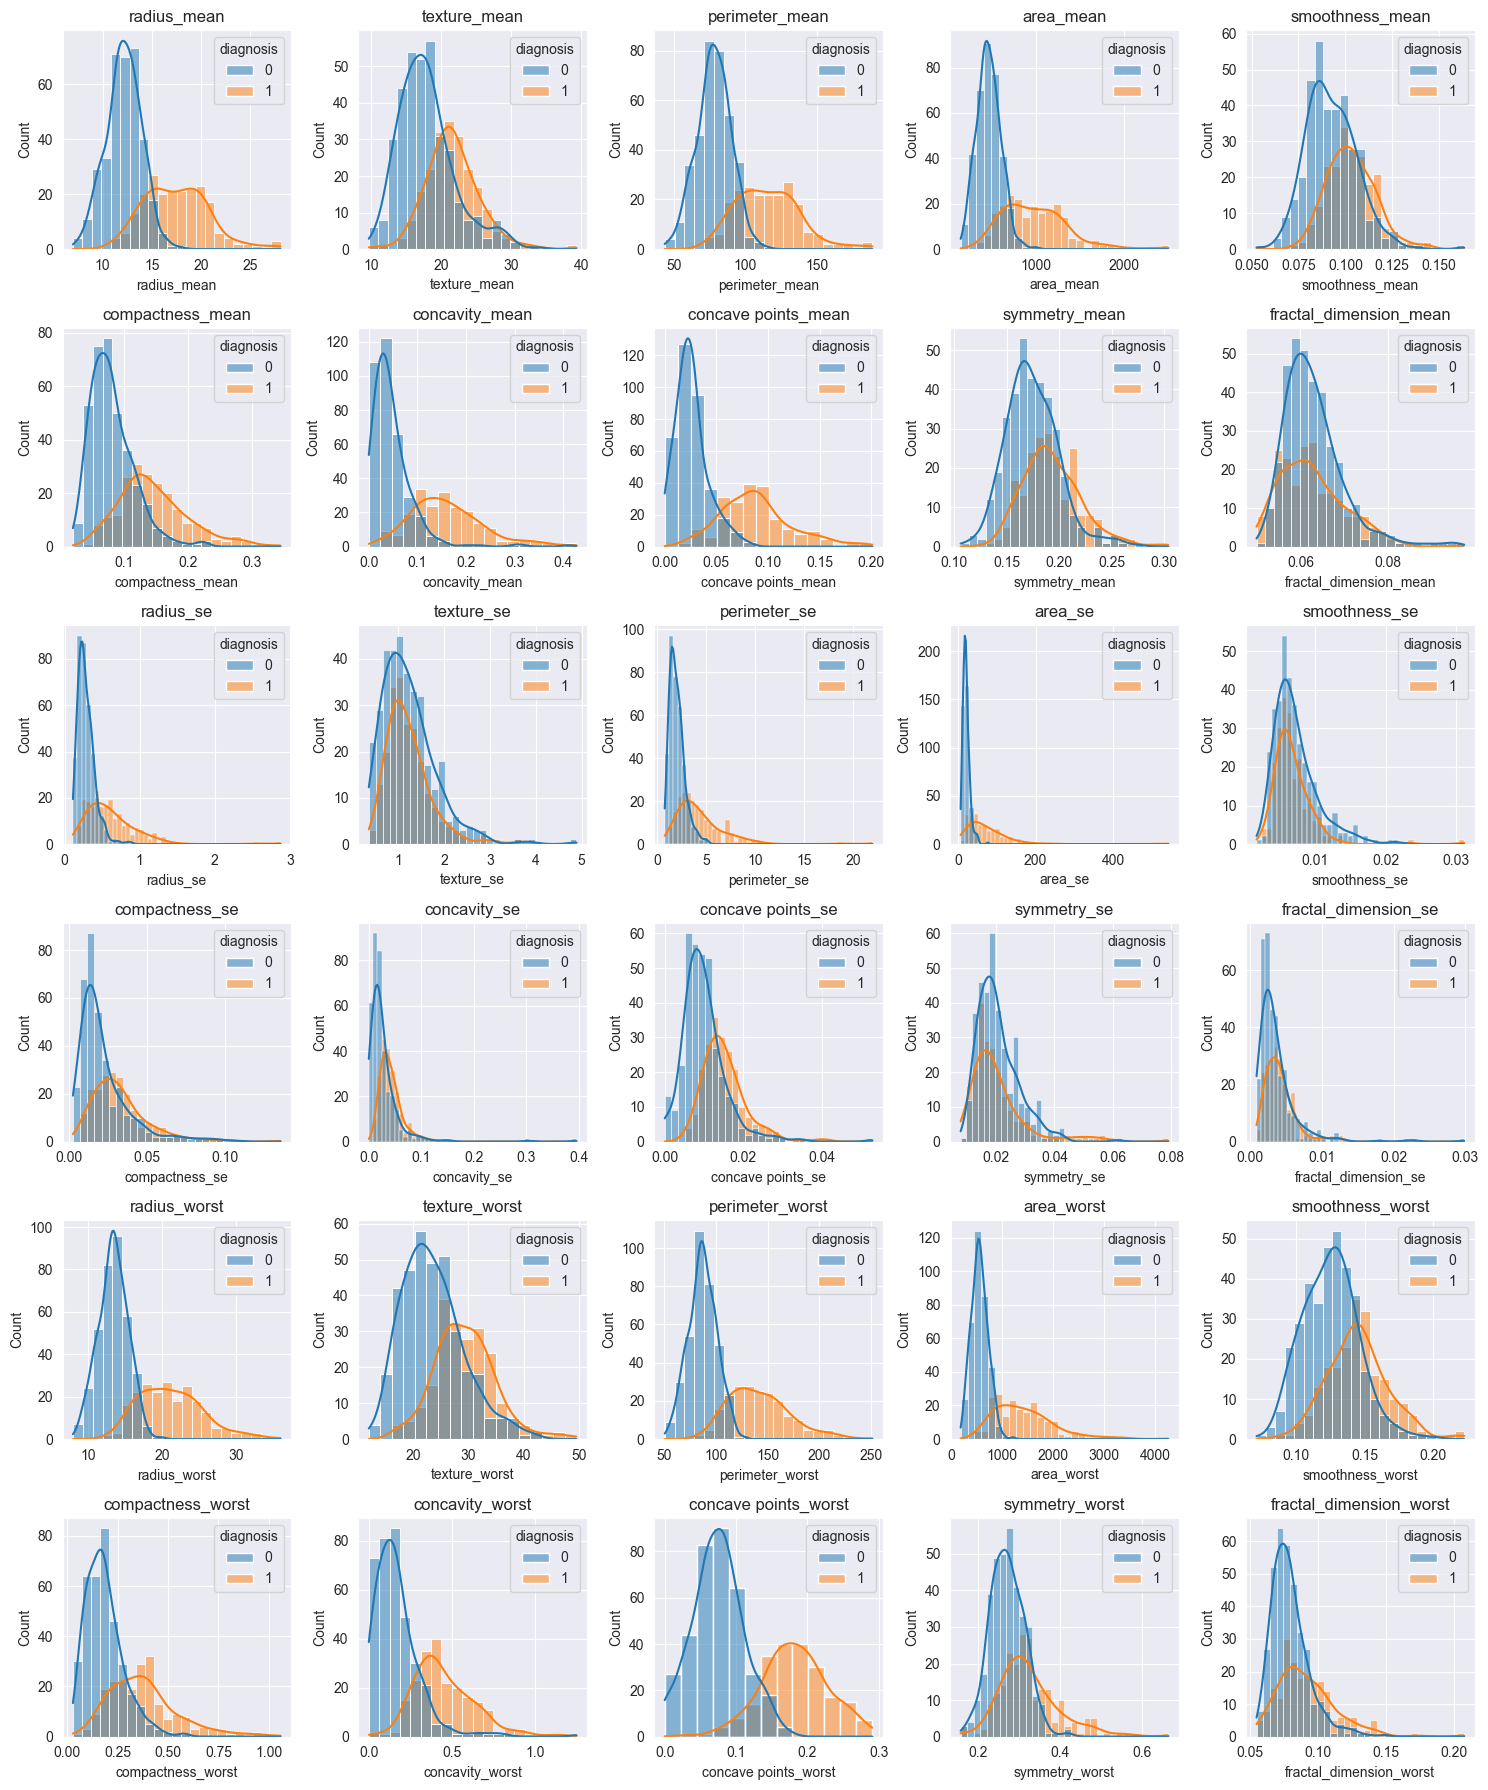

In [13]:
#histograms

fig, axes = plt.subplots(6,5, figsize=(15,18))

axes = axes.flatten()

for i, col in enumerate(df.columns[1:]):

    sns.histplot(
        data=df,
        x=col,
        hue='diagnosis',
        ax=axes[i],
        kde=True
    )

    axes[i].set_title(col)

plt.tight_layout()

plt.show()


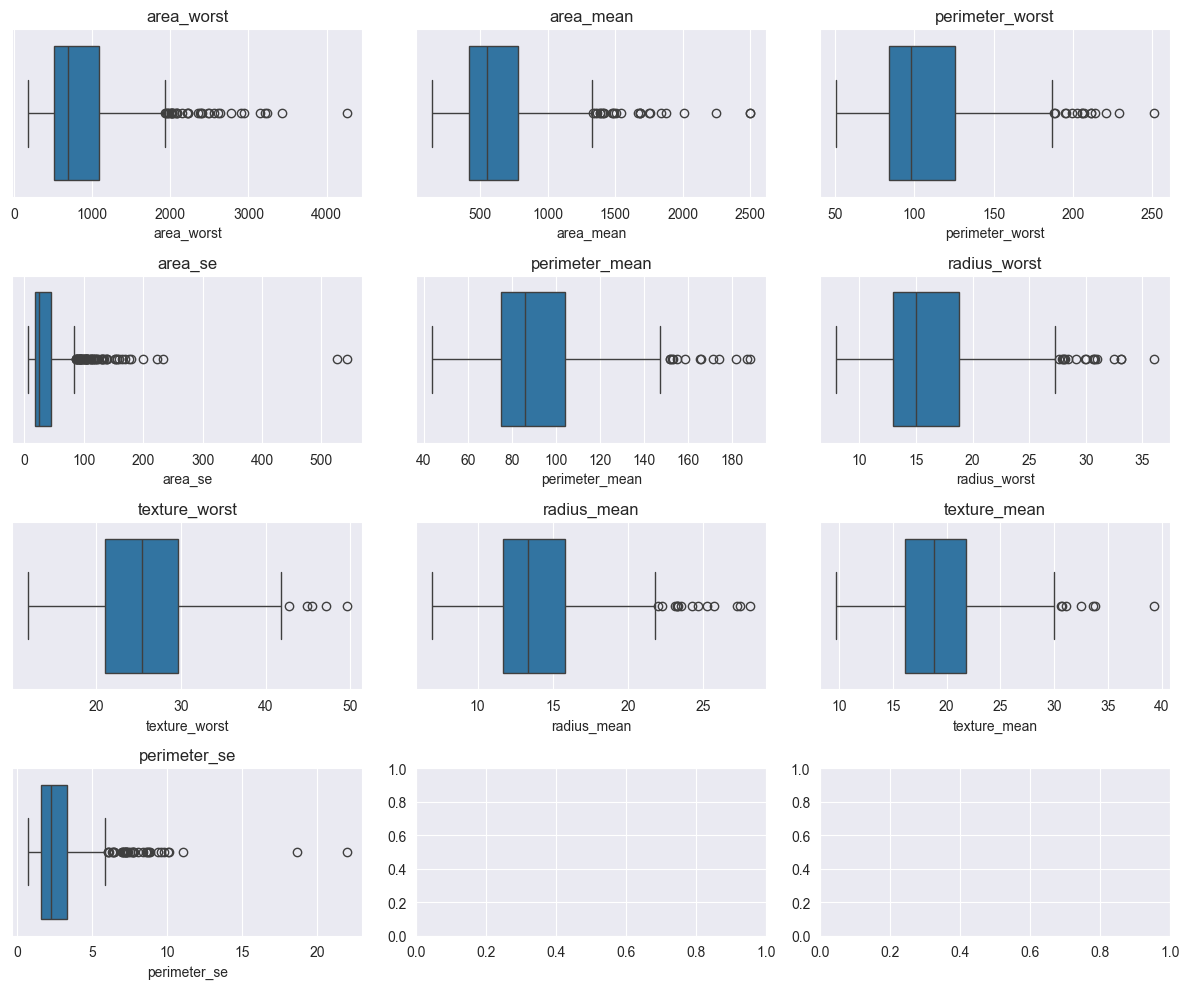

In [14]:
#boxplots

fig, axes = plt.subplots(4,3, figsize=(12,10))

axes = axes.flatten()

for i, col in enumerate(top_10_features):

    sns.boxplot(df, x=col, ax=axes[i])

    axes[i].set_title(col)

plt.tight_layout()

plt.show()

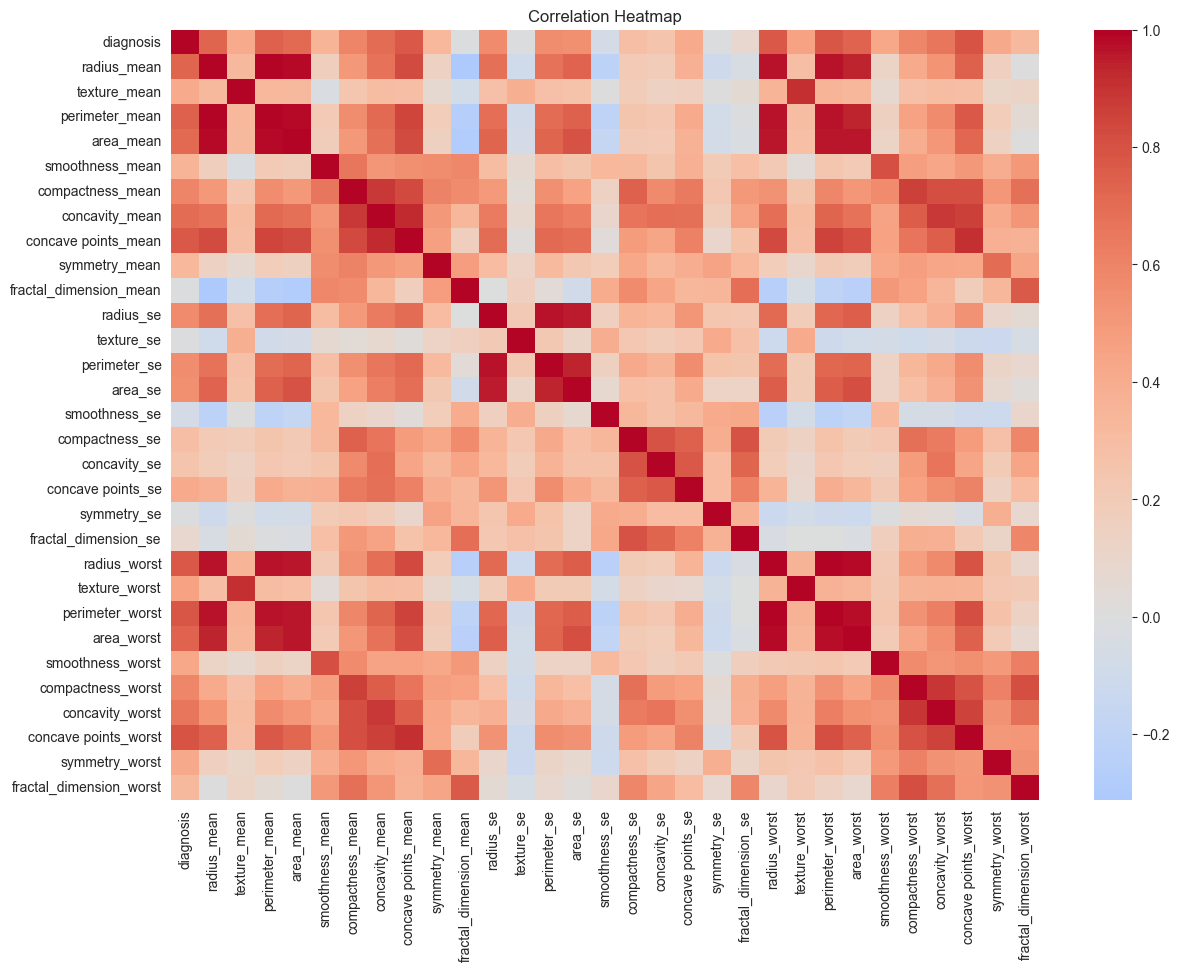

In [15]:
#heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')

plt.show()

FEATURE ENGINEERING

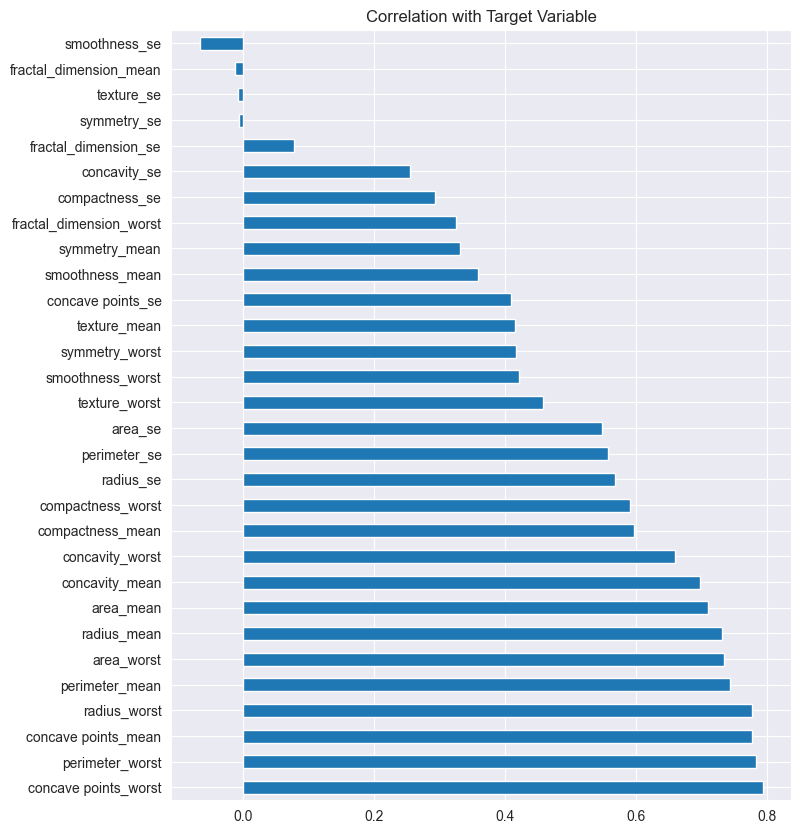

In [16]:
corr_target = df.corr()['diagnosis'].sort_values(
    ascending=False
)

plt.figure(figsize=(8,10))

corr_target.drop('diagnosis').plot(kind='barh')

plt.title('Correlation with Target Variable')

plt.show()

In [17]:
# Remove highly correlated features

corr_matrix = df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column for column in upper.columns
    if any(upper[column] > 0.9)
]

print("Features to drop:", to_drop)

df.drop(to_drop, axis=1, inplace=True)

Features to drop: ['perimeter_mean', 'area_mean', 'concave points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'concave points_worst']


In [18]:
#winsorization
df_winsorized = df.copy()

num_cols = df_winsorized.drop(
    'diagnosis',
    axis=1
).columns

for col in num_cols:

    df_winsorized[col] = winsorize(
        df_winsorized[col],
        limits=[0.05, 0.05]
    )

df = df_winsorized.copy()

df.head()


,diagnosis,radius_mean,texture_mean,smoothness_mean,compactness_mean,concavity_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,smoothness_worst,compactness_worst,concavity_worst,symmetry_worst,fractal_dimension_worst
0,1,17.990,13.080,0.118,0.209,0.244,0.231,0.076,0.962,0.905,0.006,0.049,0.054,0.016,0.030,0.006,0.162,0.565,0.683,0.407,0.119
1,1,20.570,17.770,0.085,0.079,0.087,0.181,0.057,0.543,0.734,0.005,0.013,0.019,0.013,0.014,0.004,0.124,0.187,0.242,0.275,0.089
2,1,19.690,21.250,0.110,0.160,0.197,0.207,0.060,0.746,0.787,0.006,0.040,0.038,0.021,0.022,0.005,0.144,0.424,0.450,0.361,0.088
3,1,11.420,20.380,0.119,0.209,0.241,0.231,0.076,0.496,1.156,0.009,0.061,0.057,0.019,0.035,0.008,0.172,0.565,0.683,0.407,0.120
4,1,20.290,14.340,0.100,0.133,0.198,0.181,0.059,0.757,0.781,0.011,0.025,0.057,0.019,0.018,0.005,0.137,0.205,0.400,0.236,0.077


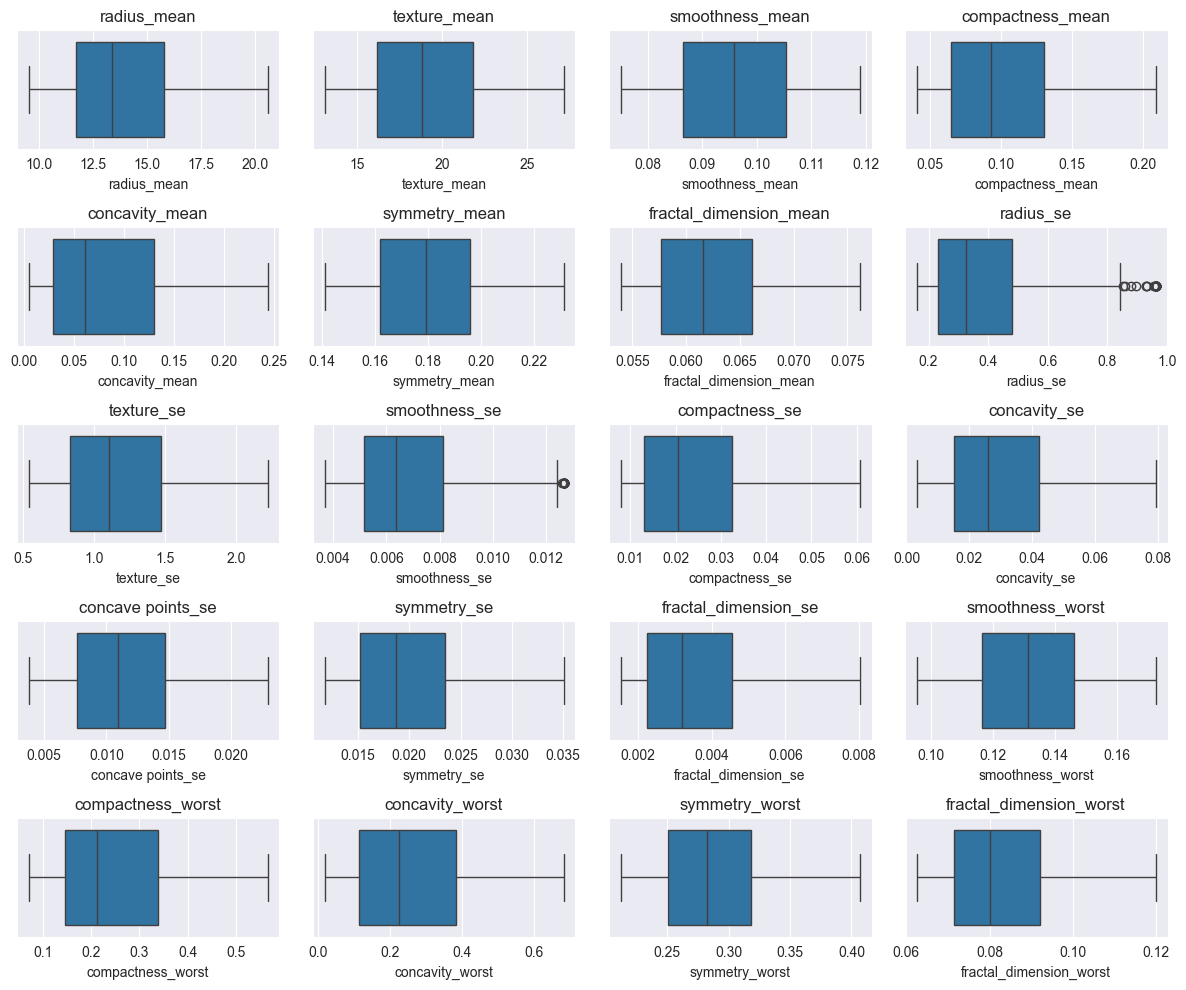

In [ ]:
# Boxplots

cols = df.drop('diagnosis', axis=1).columns

fig, axes = plt.subplots(5,4, figsize=(12,10))

axes = axes.flatten()

for i, col in enumerate(cols):

    sns.boxplot(x=df[col], ax=axes[i])

    axes[i].set_title(col)

plt.tight_layout()

plt.show()

Train test Split

In [21]:
x = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [22]:

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [24]:
# Save datasets
joblib.dump(x_train, '../Models/x_train.pkl')
joblib.dump(x_test, '../Models/x_test.pkl')
joblib.dump(y_train, '../Models/y_train.pkl')
joblib.dump(y_test, '../Models/y_test.pkl')


['../Models/y_test.pkl']